In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize_scalar
from scipy.integrate import quad
import matplotlib.pyplot as plt

In [434]:
# USER TABLE EXAMPLE
user_array_1 = np.array([
    [4, 3.8, 0, 500] for i in range(4)
])

user_array_2 = np.array([
    [4, 3.8, 0, 10] for i in range(200)
])

user_array_3 = np.array([
    [4, 3.8, 0, 2000]
])

user_array = np.array([
    [4, 3.8, 0.5, 276],
    [3, 2.8, 0.5, 831],
    [2, 1.8, 0.5, 137]
])

user_table_raw_1 = pd.DataFrame(user_array_1, columns=['pipe_outer_diameter', 'pipe_inner_diameter', 'insulation_thickness', 'segment_length'])
user_table_raw_2 = pd.DataFrame(user_array_2, columns=['pipe_outer_diameter', 'pipe_inner_diameter', 'insulation_thickness', 'segment_length'])
user_table_raw_3 = pd.DataFrame(user_array_3, columns=['pipe_outer_diameter', 'pipe_inner_diameter', 'insulation_thickness', 'segment_length'])
user_table = pd.DataFrame(user_array, columns=['pipe_outer_diameter', 'pipe_inner_diameter', 'insulation_thickness', 'segment_length'])

# PROPERTIES TABLE EXAMPLE
properties_table = pd.Series([70, 68, 60, 9.7, 0.025, 24155, 1, 5, 1], index=['inlet_temperature', 'ambient_temperature', 'h_fluid_to_pipe', 'k_pipe', 'k_insulation', 'mass_flow_rate', 'specific_heat_capacity', 'solar_flux', 'emissivity'])


In [435]:
class Air:

    '''
    Describes air properties around piping. 
    Provides all necessary functions for heat transfer coefficient determination.
    
    Parameters
    ----------
    outer_diameter: float, array-like
    	Piping outer diameter [inch]
    insulation_thickness: float, array-like
    	Insulation thickness [inch]
    ambient_temperature: float, array-like
    	Ambient temperature [K]
    emissivity: float
    	Piping surface emissivity []
    
    Returns
    -------
    Air_class: 
    	Air class.
    '''
    
    def __init__(
        self,
        outer_diameter,
        insulation_thickness,
        ambient_temperature,
        emissivity
    ):

        self.total_diameter = outer_diameter + 2 * insulation_thickness
        self.ambient_temperature = ambient_temperature
        self.emissivity = emissivity
        
    
    def cp(
        self,
        ref_temperature
    ):

        '''
        Calculate specific heat capacity of air at reference temperature, which is film temperature of air around piping.
        Model is taken from Cengel, and is fitted to a range 273K - 1800K. Below 273K cp is equal to cp at 273K and above 
        1800K cp is equal to cp at 1800K.
    
        Parameters
        ----------
        ref_temperature: float, array_like
            Reference temperature at insulation-air interface [K]
    
        Returns
        -------
        _cp: float, array_like
            Specific heat capacity [kJ/kg.K]
        '''        
        
        # all constants here come from "Thermodynamics: An Engineering Approach" by Y. Cengel
        _cp_f = lambda ref_temperature: (28.11 + 0.1967e-2 * ref_temperature + 0.4802e-5 * ref_temperature ** 2 - 1.966e-9 * ref_temperature ** 3) / 28.96
        
        # going with np.array below assures that even when ref_temp is int all calculations carry on
        _cp = np.array(_cp_f(ref_temperature))
        _cp[ref_temperature < 273] = _cp_f(273)
        _cp[ref_temperature > 1800] = _cp_f(1800)
        return _cp

    def u(
        self,
        ref_temperature
    ):
    
        '''
        Calculate kinematic viscosity of air at reference temperature, which is film temperature of air around piping.
    
        Parameters
        ----------
        ref_temperature: float, array_like
            Reference temperature at insulation-air interface [K]
    
        Returns
        -------
        _u: float, array_like
            Kinematic viscosity [Pa*s]
        '''
    
        # Sutherland's Law
        _u = 1.458e-6 * ref_temperature ** 1.5 / (ref_temperature + 110.4)
        return _u
    
    def Ra(
        self,
        ambient_temperature,
        surface_temperature,
    ):
    
        '''
        Calculate Rayleigh number of air at film temperature for horizontal cylindrical body. 
        It is assummed that Pr=0.72 for air in all temperature range.
    
        Parameters
        ----------
        surface_temperature: float, array_like
            Insulation surface temperature [K]
        ambient_temperature: float
            Ambient temperature around piping [K]
    
        Returns
        -------
        _Ra: float, array_like
            Rayleigh number.
        '''

        film_temperature = (surface_temperature + ambient_temperature) / 2
    
        # Pr = 0.72 -> mean value for air on range from 220K to 2200K
        # g = 9.81 -> gravitational acceleration
        # P / R = 101.325 / 0.287 -> atmospheric pressure over gas constant for air
        # 0.0254 -> conversion from inch to meter
        _Ra = 0.72 * 9.81 * (101.325 / 0.287) ** 2 *\
            np.abs(surface_temperature - ambient_temperature) / (film_temperature ** 3 * self.u(film_temperature) ** 2) *\
            (self.total_diameter * 0.0254) ** 3
        
        return _Ra
    
    def h_combined(
        self,
        surface_temperature
    ):
    
        '''
        Calculate combined heat transfer coefficient at insulation-air interface.
        Radiation heat transfer coeff. is in its typical form.
        Convective heat transfer is based on Churchill and Chu correlation formula.
    
        Parameters
        ----------
        surface_temperature: float, array_like
            Insulation surface temperature [F]
    
        Returns
        -------
        _h_comb_vec: array_like
            Array with heat transfer coefficients of radiative and convective effects.
        '''
    
        surface_temperature_R = surface_temperature + 459.67
        ambient_temperature_R = self.ambient_temperature + 459.67
    
        # 1.71E-9 -> Stefan-Boltzmann constant
        h_rad = self.emissivity * 1.71E-9 *\
                (surface_temperature_R ** 2 + ambient_temperature_R ** 2) *\
                (surface_temperature_R + ambient_temperature_R)
    
        surface_temperature_K = surface_temperature_R * 5/9
        ambient_temperature_K = ambient_temperature_R * 5/9
        film_temperature_K = (surface_temperature_K + ambient_temperature_K) / 2
    
        # 0.1762280394 -> conversion from W/m.K to BTU/ft.h.F
        # 1000 -> conversion from kW to W
        # Pr = 0.72 -> mean value for air on range from 220K to 2200K
        # 0.6 + 0.387 / 1.20326 -> constants from Churchill and Chu correlation assuming Pr=0.72
        # 0.0254 -> conversion from inch to meters
        h_conv = 0.1762280394 * 1000 / 0.72 *\
                 (0.6 + 0.387 / 1.20326 * self.Ra(surface_temperature_K, ambient_temperature_K) ** (1/6)) ** 2 *\
                 self.u(film_temperature_K) * self.cp(film_temperature_K) / (self.total_diameter * 0.0254)
    
        _h_comb_vec = np.c_[h_rad, h_conv]
    
        return _h_comb_vec

In [450]:
class Piping_Segment:

    '''
    Describes one piping section defined by user.

    Parameters
    ----------
    outer_diameter: float
        Outer diameter [inch]
    inner_diameter: float
        Inner diameter [inch]
    insulation_thickness: float
        Insulation thickness [inch]
    segment_length: float
        Length of pipng segment [ft]
    start_length: float
        Initial cumulative length. If there is more than one segment, then start_length_i = end_segment_(i-1) [F]
    inlet_temperature: float
        Temperature at start length. If there is more than one segment, then inlet_temperature_i = final_temperature_(i-1) [F]
    ambient_temperature: float
        Ambient temperature [F]
    h_fluid_to_pipe: float
        Heat transfer coeff from fluid to wall of piping [BTU/ft2.h.F]
    k_pipe: float
        Thermal conductivity of piping material [BTU/ft.h.F]
    k_insulation: float
        Thermal conductivity of insulation material [BTU/ft.h.F]
    mass_flow_rate: float
        Mass flow rate [lbm/h]
    specific_heat_capacity: float
        Specific heat capacity of liquid [BTU/lbm.R]
    h_combined_func: function
        Function for calculating combined heat transfer coeff. Must take one argument only []
    
    Returns
    -------
    Piping_Segment_class: 
        Piping segment class.
    '''
    
    def __init__(
        self,
        outer_diameter,
        inner_diameter,
        insulation_thickness,
        segment_length,
        start_length,
        inlet_temperature,
        ambient_temperature,
        h_fluid_to_pipe, 
        k_pipe, 
        k_insulation,
        mass_flow_rate,
        specific_heat_capacity,
        solar_flux,
        h_combined_func
    ):

        # piping geometry
        self.outer_diameter = outer_diameter
        self.inner_diameter = inner_diameter
        self.insulation_thickness = insulation_thickness
        self.segment_length = segment_length
        self.start_length = start_length
        self.total_diameter = self.outer_diameter + 2 * self.insulation_thickness
        self.end_length = self.start_length + self.segment_length
        
        # piping thermal properties
        self.h_fluid_to_pipe = h_fluid_to_pipe
        self.k_pipe = k_pipe
        self.k_insulation = k_insulation

        # fluid properties
        self.inlet_temperature = inlet_temperature
        self.ambient_temperature = ambient_temperature
        self.mass_flow_rate = mass_flow_rate
        self.specific_heat_capacity = specific_heat_capacity

        # add heat rate per segment length, that will be populated during solution for total piping
        self.heat_rate_psl_total = 0
        self.heat_rate_psl_surface = 0 

        # heat transfer coefficient functoin
        self.h_comb_vec = lambda T_surface: h_combined_func(T_surface)
        self.h_comb_func = lambda T_surface: h_combined_func(T_surface).sum(1)

        # define derivative function
        self.derivative = lambda f, x: ( f(x+0.00001) - f(x-0.00001) ) / 0.00002

        # find inlet surface temperature
        self.find_inlet_surface_temperature()
        
        # set normal bounds for find_surface_temperature
        # we use sorted() for when inlet temperature is lower than ambient temperature
        self.bounds=sorted([self.ambient_temperature, self.inlet_surface_temperature])

        # solar flux
        self.solar_flux = solar_flux
        if solar_flux > 0:
            self.solar_radiation_helper()

    def K(
        self,
        T_surface
    ):
    
        '''
        Calculate combined thermal conductivity.
    
        Parameters
        ----------
        T_surface: float, array_like
            Insulation surface temperature [F]
    
        Returns
        -------
        _K: float, array_like
            Combined thermal conductivity [BTU/ft.h.F]
        '''

        _R = (12 * 2) / (self.h_fluid_to_pipe * self.inner_diameter) +\
             np.log( self.outer_diameter / self.inner_diameter ) / self.k_pipe +\
             np.log( self.total_diameter / self.outer_diameter ) / self.k_insulation +\
             (12 * 2) / (self.h_comb_func(T_surface) * self.total_diameter)
    
        self.K_combined = 1 / _R

        return self.K_combined


    def ratio_of_resistances(
        self,
        T_surface
    ):

        '''
        Calculate ratio of thermal resistances. The returned ratio finds R_fa/R_sa where
        R_fa = 1/(2*pi*K)
        R_sa = 24/(2*pi*D*h).

        Parameters
        ----------
        T_surface: float
        	Insulation surface temperature [F]
        
        Returns
        -------
        _res_ratio: float
        	Calculated resistance ratio.
        '''

        _res_ratio = self.total_diameter * self.h_comb_func(T_surface) / (24 * self.K(T_surface))

        return _res_ratio
    
    def find_fluid_temperature(
        self, 
        T_surface
    ):
    
        '''
        Calculate fluid temperature at provided surface temperature.
    
        Parameters
        ----------
        T_surface: float, array_like
            Insulation surface temperature [F]
    
        Returns
        -------
        _T_fluid: float, array_like
            Temperature calculated at provided surface temperature [F]
        '''

        _T_fluid = self.ambient_temperature + (T_surface - self.ambient_temperature) *\
                    self.ratio_of_resistances(T_surface)
    
        self.fluid_temperature = _T_fluid

        return self.fluid_temperature

    def find_inlet_surface_temperature(
        self
    ):
        '''
        Calculate inlet surface temperature.

        Function minimizez squared difference of:
        R_fa/R_sa*(Ts-Ta)-(Tf-Ta)

        Parameters
        ----------
        
        Returns
        -------
        self.inlet_surface_temperature: float
        	Inlet surface temperature.
        '''

        _T_surf_loss_func = lambda T_surface: (
            (T_surface - self.ambient_temperature) * self.ratio_of_resistances(T_surface) -\
            (self.inlet_temperature - self.ambient_temperature)
        ) ** 2

        # we use sorted() for when inlet temperature is lower than ambient temperature
        self.minim_inlet_surface_temperature = minimize_scalar(
            _T_surf_loss_func,
            bounds=sorted([self.ambient_temperature, self.inlet_temperature])
        )

        # make sure to extract float, so scipy can accept it
        self.inlet_surface_temperature = self.minim_inlet_surface_temperature.x[0]

    def solar_radiation_helper(
        self,
        threshold=0.01
    ):
        
        # initiate by finding inlet surface temperature
        self.find_inlet_surface_temperature()
        
        # calculate constant temperature solar flux
        self.const_temp_sol_flux = self.h_comb_func(self.inlet_surface_temperature) \
                                    * (self.inlet_surface_temperature - self.ambient_temperature)

        # find how close provided solar flux is to constant temp solar flux
        _closeness = self.solar_flux / self.const_temp_sol_flux - 1

        _loss = lambda T_s: ( self.h_comb_func(T_s) * (T_s - self.ambient_temperature) - self.solar_flux ) ** 2

        if _closeness >= 0:
            
            upper_bound = minimize_scalar(_loss).x[0]
            self.bounds = sorted([self.ambient_temperature, upper_bound])

            if _closeness <= threshold:
                self.solar_flux = (1 + threshold) * self.const_temp_sol_flux

        else:

            lower_bound = minimize_scalar(_loss).x[0]
            self.bounds = sorted([lower_bound, self.inlet_surface_temperature])

            if _closeness >= -threshold:
                self.solar_flux = (1 - threshold) * self.const_temp_sol_flux

    def integrand(
        self,
        T_surface
    ):
        '''
        Find value of integrand, given surface temperature.

        Parameters
        ----------
        T_surface: float
        	Insulation surface temperature [F]
        
        Returns
        -------
        _integrand: float
        	Calculated integrand.
        '''

        ln_res_ratio = lambda T_surface: np.log(self.ratio_of_resistances(T_surface))

        _I = 1 / self.K(T_surface) * ( 1 / (T_surface - self.ambient_temperature) + self.derivative(ln_res_ratio, T_surface) )

        _integrand = _I / ( 1 - self.solar_flux / (self.h_comb_func(T_surface) * (T_surface - self.ambient_temperature)) )

        # make sure to extract float, so scipy can accept it
        return _integrand[0]

    def integral_loss_function(
        self,
        T_surface,
        length
    ):

        '''
        Calculates squared sum of integral over surface temperature and integral over distance.

        Parameters
        ----------
        T_surface: float
        	Insulation surface temperature [F]
        length: float
        	Distance at which to find surface temperature [ft]
        
        Returns
        -------
        loss_function: float
        	Calculated loss.
        '''
        
        _lambda = self.mass_flow_rate * self.specific_heat_capacity / (2 * np.pi)
        integral = quad(self.integrand, self.inlet_surface_temperature, T_surface, limit=500)
        loss = (integral[0] + length / _lambda) ** 2

        return loss

    def find_surface_temperature(
        self,
        length
    ):

        '''
        Finds surface temperature, at specified length by minimizing integral_loss_funciton.

        Parameters
        ----------
        length: float
        	Distance at which to find surface temperature [ft]
        
        Returns
        -------
        self.surface_temperature: float
        	Surface temperature.
        '''

        self.minim_surface_temperature = minimize_scalar(
            self.integral_loss_function,
            bounds=self.bounds,
            args=(length)
        )

        self.surface_temperature = self.minim_surface_temperature.x
        
        return self.surface_temperature
        
    def temperature_profile(self, n=2):

        '''
        Find fluid temperature over a whole segment.
        Parameter n controls to how many parts a given segment is to be split to.
        Calculations are carried out by filling separate lists, and then they are combined
        to one pandas dataframe. At the end, this dataframe is saved into class as "temp_prof".
        
        Parameters
        ----------
        n: int
        	Number of parts to split the given segment to. Default n=2 []
        
        Returns
        -------
        self.temp_prof: pd.DataFrame
        	Temperature profile.
        '''

        # initialize at x=0
        temp_profile = [self.inlet_temperature]
        surf_temp_profile = [self.inlet_surface_temperature]
        segment_length = [0]

        # run through rest n-1 segments
        for _l in np.linspace(self.segment_length / (n - 1), self.segment_length, n - 1):
 
            _T_surf_l = self.find_surface_temperature(_l)
            _T_l = self.find_fluid_temperature(_T_surf_l)

            temp_profile.append(_T_l[0])
            surf_temp_profile.append(_T_surf_l)
            segment_length.append(_l)

        _result_df = pd.DataFrame(
            np.c_[segment_length, temp_profile, surf_temp_profile],
            columns=["length", "temp", "surf_temp"]
        )

        self.temp_prof = _result_df

        return self.temp_prof

In [457]:
def find_heat_rates(piping_segment, n=2):
    ps = piping_segment
    total_heat_rate_out = -ps.mass_flow_rate * ps.specific_heat_capacity * (ps.temp_prof["temp"][n-1] - ps.inlet_temperature) / ps.segment_length
    dtr = np.array(ps.temp_prof["surf_temp"][0] + 1 * ps.temp_prof["surf_temp"].diff().dropna() - ps.ambient_temperature) / (ps.temp_prof.loc[1, 'temp'] - ps.ambient_temperature) * ps.total_diameter / 24
    _lmtd = LMTD(*ps.temp_prof['temp'][[0, n-1]], ps.ambient_temperature)
    h = lambda w: ps.h_comb_vec(ps.temp_prof["surf_temp"][0] + w * ps.temp_prof["surf_temp"].diff().dropna())
    total_heat_from_h_vec = lambda w: 2 * np.pi * dtr * h(w) * _lmtd
    _loss = lambda w: (total_heat_rate_out - total_heat_from_h_vec(w).sum()) ** 2
    w_minim = minimize_scalar(_loss, bounds=[0, 1]).x
    return total_heat_rate_out, total_heat_from_h_vec(1)

In [458]:
def LMTD(T_i, T_e, T_a):

    '''
    Find Log-mean temperature difference.

    Parameters
    ----------
    T_i: float, array-like
    	Inlet temperature [F]
    T_e: float, array-like
    	Exit temperature [F]
    T_a: float, array-like
    	Ambient temperature [F]
    
    Returns
    -------
    _lmtd: float, array-like
    	Log-mean temperature difference.
    '''
    
    # use np.abs for cases when fluid temperature is less than ambient temperature
    _lmtd = ( T_i - T_e ) / ( np.log(np.abs(T_i - T_a)) - np.log(np.abs(T_e - T_a)) )
    return _lmtd

def calculate_total_piping(piping_class, air_surface_class, user_table, properties_table, n=2):

    '''
    Calculate all pipng segments provided by user.
    
    Parameters
    ----------
    piping_class: class object
    	Piping_Segment []
    air_surface_class: class object
    	Air []
    user_table: pd.DataFrame
    	Table specified by user, defining all piping segments []
    properties_table: pd.DataFrame
    	Table specified by user, defining all required properties []
    n: int
    	Number of parts to split the given segment to. Default n=2 []
    
    Returns
    -------
    class_list: list
    	List containing solved Piping_Segment classes for each segment specified by user.
    '''
 
    class_list = []

    for i in range(0, user_table.shape[0]):

        # load air class
        a = air_surface_class(*user_table.loc[i, ['pipe_outer_diameter', 'insulation_thickness']], *properties_table[['ambient_temperature', 'emissivity']])
        
        # load piping class
        if i == 0:
            ps = piping_class(*user_table.loc[0, :], 0, *properties_table[:-1], a.h_combined)
        else:
            ps = piping_class(*user_table.loc[i, :], ps.end_length, ps.temp_prof.loc[n-1, 'temp'], *properties_table[1:-1], a.h_combined)

        # find temperature profile
        ps.temperature_profile(n=n)

        # load heat rates
        ps.heat_rate_psl_total, ps.heat_rate_psl_surface = find_heat_rates(ps, n)

        # append the list
        class_list.append(ps)
    
    return class_list

def final_table(piping_segment_class_list):

    '''
    Takes output from calculate_total_piping and converts it to easy to read pandas DataFrame.
    
    Parameters
    ----------
    piping_segment_class_list: list
    	List containing solved Piping_Segment classes for each segment specified by user []
    
    Returns
    -------
    _final_table: pd.DataFrame
    	Table containing all solved piping segments.
    '''

    # make sure n=2
    assert(piping_segment_class_list[0].temp_prof.shape[0] == 2), print('Number of points must be n=2')
    
    _final_table = pd.DataFrame(
        index=np.arange(0, len(piping_segment_class_list)),
        columns=[
            'segment_length',
            'temperature_inlet',
            'temperature_outlet',
            'surface_temperature_inlet',
            'surface_temperature_outlet',
            'heat_sum',
            'heat_by_radiation',
            'heat_by_convection'
        ],
        dtype=float
    )       
    
    for i in range(len(piping_segment_class_list)):

        _final_table.loc[i, 'segment_length'] = piping_segment_class_list[i].segment_length
        _final_table.loc[i, ['temperature_inlet', 'temperature_outlet']] = piping_segment_class_list[i].temp_prof['temp'].values
        _final_table.loc[i, ['surface_temperature_inlet', 'surface_temperature_outlet']] = piping_segment_class_list[i].temp_prof['surf_temp'].values
        _final_table.loc[i, 'heat_sum'] = piping_segment_class_list[i].heat_rate_psl_total
        _final_table.loc[i, ['heat_by_radiation', 'heat_by_convection']] = piping_segment_class_list[i].heat_rate_psl_surface

    return _final_table

def final_table_units_handler(piping_segment_class_list, units):

    '''
    Converts final table to correct units.

    Parameters
    ----------
    piping_segment_class_list: list
    	List containing solved Piping_Segment classes for each segment specified by user []
    units: str
        Either "SI" or "Imperial" []

    Returns
    -------
    _uh_final_table: pd.DataFrame
        Final table.
    '''

    _uh_final_table = final_table(piping_segment_class_list)

    rename_columns = lambda length, temp, heat: [
        f'Segment Length [{length}]',
        f'Temperature Inlet [{temp}]',
        f'Temperature Outlet [{temp}]',
        f'Surface Temperature Inlet [{temp}]',
        f'Surface Temperature Outlet [{temp}]',
        f'Heat Transfer Total [{heat}]',
        f'Heat Transfer by Radiation [{heat}]',
        f'Heat Transfer by Convection [{heat}]'
    ]

    length, temp, heat = ['ft', 'F', 'BTU/h.ft']

    if units.lower() == 'si':
        length, temp, heat = ['m', 'C', 'W/m']
        _uh_final_table['segment_length'] = _uh_final_table['segment_length'] * 0.3048 # 1 ft = 0.3048 m
        _uh_final_table['temperature_inlet'] = (_uh_final_table['temperature_inlet'] - 32) / 1.8
        _uh_final_table['temperature_outlet'] = (_uh_final_table['temperature_outlet'] - 32) / 1.8
        _uh_final_table['surface_temperature_inlet'] = (_uh_final_table['surface_temperature_inlet'] - 32) / 1.8
        _uh_final_table['surface_temperature_outlet'] = (_uh_final_table['surface_temperature_outlet'] - 32) / 1.8
        _uh_final_table['heat_sum'] = _uh_final_table['heat_to_ins'] * 0.293071 / 0.3048 # 1 BTU/h.ft = 0.293071 / 0.3048 W/m
        _uh_final_table['heat_by_radiation'] = _uh_final_table['heat_by_radiation'] * 0.293071 / 0.3048 # 1 BTU/h.ft = 0.293071 / 0.3048 W/m
        _uh_final_table['heat_by_convection'] = _uh_final_table['heat_by_convection'] * 0.293071 / 0.3048 # 1 BTU/h.ft = 0.293071 / 0.3048 W/m

    _uh_final_table.columns = rename_columns(length, temp, heat)

    return _uh_final_table.round(2)

In [459]:
cl_1 = calculate_total_piping(Piping_Segment, Air, user_table_raw_1, properties_table)
cl_2 = calculate_total_piping(Piping_Segment, Air, user_table_raw_2, properties_table)
cl_3 = calculate_total_piping(Piping_Segment, Air, user_table_raw_3, properties_table)

In [460]:
A1 = final_table_units_handler(cl_1, 'imperial')
A2 = final_table_units_handler(cl_2, 'imperial')
A3 = final_table_units_handler(cl_3, 'imperial')

In [461]:
A1

,Segment Length [ft],Temperature Inlet [F],Temperature Outlet [F],Surface Temperature Inlet [F],Surface Temperature Outlet [F],Heat Transfer Total [BTU/h.ft],Heat Transfer by Radiation [BTU/h.ft],Heat Transfer by Convection [BTU/h.ft]
0,500.0,70.00,70.05,69.95,70.00,-2.40,2.09,0.75
1,500.0,70.05,70.10,70.00,70.05,-2.33,2.14,0.77
2,500.0,70.10,70.14,70.05,70.09,-2.26,2.19,0.79
3,500.0,70.14,70.19,70.09,70.14,-2.19,2.24,0.81


In [463]:
A2

,Segment Length [ft],Temperature Inlet [F],Temperature Outlet [F],Surface Temperature Inlet [F],Surface Temperature Outlet [F],Heat Transfer Total [BTU/h.ft],Heat Transfer by Radiation [BTU/h.ft],Heat Transfer by Convection [BTU/h.ft]
0,10.0,70.00,70.00,69.95,69.95,-2.44,2.06,0.73
1,10.0,70.00,70.00,69.95,69.95,-2.44,2.07,0.73
2,10.0,70.00,70.00,69.95,69.95,-2.44,2.07,0.73
3,10.0,70.00,70.00,69.95,69.95,-2.44,2.07,0.73
4,10.0,70.00,70.01,69.95,69.96,-2.43,2.07,0.73
...,...,...,...,...,...,...,...,...
195,10.0,70.19,70.19,70.13,70.13,-2.16,2.26,0.82
196,10.0,70.19,70.19,70.13,70.13,-2.16,2.26,0.82
197,10.0,70.19,70.19,70.13,70.13,-2.16,2.26,0.82
198,10.0,70.19,70.19,70.13,70.13,-2.16,2.26,0.82


In [464]:
A3

,Segment Length [ft],Temperature Inlet [F],Temperature Outlet [F],Surface Temperature Inlet [F],Surface Temperature Outlet [F],Heat Transfer Total [BTU/h.ft],Heat Transfer by Radiation [BTU/h.ft],Heat Transfer by Convection [BTU/h.ft]
0,2000.0,70.0,70.19,69.95,70.14,-2.29,2.16,0.78


In [349]:
cl_3[0].total_diameter

4.0

In [298]:
cl_3[0].temp_prof

,length,temp,surf_temp
0,0.0,1880.000000,1436.629654
1,2000.0,903.513416,805.281998


In [299]:
ps = cl_3[0]

In [300]:
ps.mass_flow_rate * ps.specific_heat_capacity * (ps.inlet_temperature - ps.temp_prof["temp"][1]) / ps.segment_length

np.float64(11793.516713512674)

In [277]:
2 * np.pi * ps.K(ps.temp_prof["surf_temp"][0]) * LMTD(ps.inlet_temperature, ps.temp_prof["temp"][1], ps.ambient_temperature)

array([-114.34835382])

In [278]:
2 * np.pi * ps.K(ps.temp_prof["surf_temp"][1]) * LMTD(ps.inlet_temperature, ps.temp_prof["temp"][1], ps.ambient_temperature)

array([-112.86220148])

In [279]:
2 * np.pi * ps.K(LMTD(ps.inlet_temperature, ps.temp_prof["temp"][1], ps.ambient_temperature)) * LMTD(ps.inlet_temperature, ps.temp_prof["temp"][1], ps.ambient_temperature)

array([-122.03929427])

In [280]:
heat = lambda w: 2 * np.pi * ps.K(ps.temp_prof["surf_temp"][0] + w * ps.temp_prof["surf_temp"].diff().dropna()) * LMTD(ps.inlet_temperature, ps.temp_prof["temp"][1], ps.ambient_temperature)

In [281]:
heat_loss = lambda w: (heat(w) - ps.mass_flow_rate * ps.specific_heat_capacity * (ps.inlet_temperature - ps.temp_prof["temp"][1]) / ps.segment_length) ** 2

In [282]:
hh = np.array([heat(w) for w in np.linspace(0, 1)])

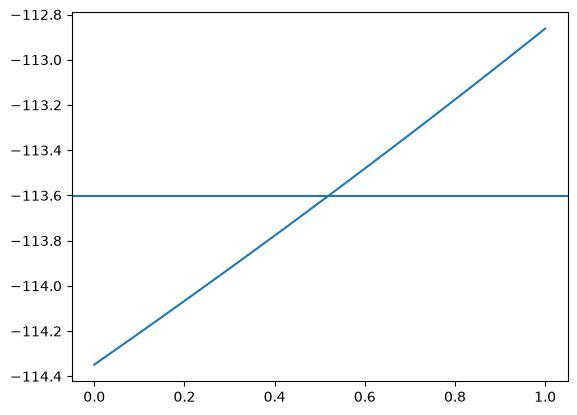

In [283]:
plt.plot(np.linspace(0, 1), hh)
plt.axhline(ps.mass_flow_rate * ps.specific_heat_capacity * (ps.inlet_temperature - ps.temp_prof["temp"][1]) / ps.segment_length)

In [284]:
for l in cl_3:
    ps = l
    heat = lambda w: 2 * np.pi * ps.K(ps.temp_prof["surf_temp"][0] + w * ps.temp_prof["surf_temp"].diff().dropna()) * LMTD(ps.inlet_temperature, ps.temp_prof["temp"][1], ps.ambient_temperature)
    heat_loss = lambda w: (heat(w) - ps.mass_flow_rate * ps.specific_heat_capacity * (ps.inlet_temperature - ps.temp_prof["temp"][1]) / ps.segment_length) ** 2
    x = minimize_scalar(heat_loss, bounds=[0, 1])
    print(x)

 message: Solution found.
 success: True
  status: 0
     fun: [ 2.153e-14]
       x: [ 5.193e-01]
     nit: 9
    nfev: 9


In [285]:
dtr = np.array(ps.temp_prof["surf_temp"][0] + 1 * ps.temp_prof["surf_temp"].diff().dropna() - ps.ambient_temperature) / (ps.temp_prof.loc[1, 'temp'] - ps.ambient_temperature) * ps.total_diameter / 24
h = ps.h_comb_vec(ps.temp_prof["surf_temp"][0] + 0.5223 * ps.temp_prof["surf_temp"].diff().dropna())
td = LMTD(*ps.temp_prof['temp'][[0, 1]], ps.ambient_temperature)

In [286]:
(2 * np.pi * dtr * h * td).sum()

np.float64(-113.62177324855125)

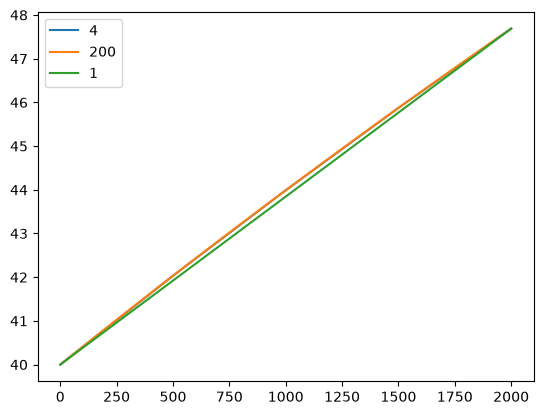

In [12]:
for cl in [cl_1, cl_2, cl_3]:
    L_t = np.array([np.linspace(c.start_length, c.end_length, 2) for c in cl])
    T_s = np.array([c.temp_prof.loc[:, 'surf_temp'] for c in cl])
    T_t = np.array([c.temp_prof.loc[:, 'temp'] for c in cl])
    plt.plot(L_t.flatten(), T_t.flatten(), label=f'{len(cl)}')
plt.legend()

In [33]:
cl = calculate_total_piping(Piping_Segment, Air, user_table, properties_table)
AA = final_table_units_handler(cl, 'imperial')

In [34]:
AA

,Segment Length [ft],Temperature Inlet [F],Temperature Outlet [F],Surface Temperature Inlet [F],Surface Temperature Outlet [F],Heat Transfer Total [BTU/h.ft],Heat Transfer by Radiation [BTU/h.ft],Heat Transfer by Convection [BTU/h.ft]
0,276.0,40.00,40.91,60.61,60.83,-14.08,-9.39,-4.69
1,831.0,40.91,43.07,61.05,61.57,-10.40,-6.92,-3.48
2,137.0,43.07,43.33,61.91,61.97,-7.16,-4.71,-2.45


In [35]:
L_t = np.array([np.linspace(c.start_length, c.end_length, 2) for c in cl])
T_s = np.array([c.temp_prof.loc[:, 'surf_temp'] for c in cl])
T_t = np.array([c.temp_prof.loc[:, 'temp'] for c in cl])

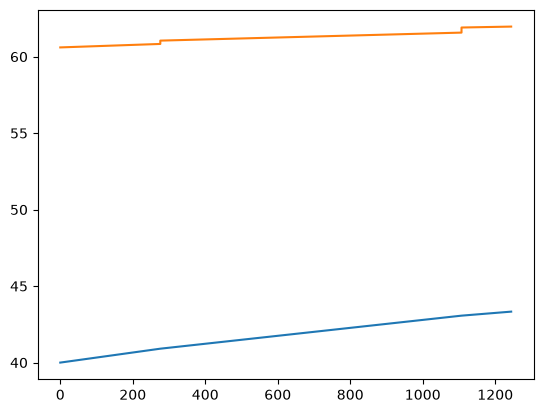

In [41]:
fig, ax = plt.subplots()
ax.plot(L_t.flatten(), T_t.flatten())
ax.plot(L_t.flatten(), T_s.flatten())

In [37]:
for i in range(3):
    print(cl[i].const_temp_sol_flux)

[-10.94584374]
[-10.36679168]
[-9.16061378]
